# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Step 1. Load the data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[["Experience Years"]]   # Feature
y = df["Salary"]               # Target

### Step 2.b print the type of each

In [4]:
X.dtypes

,0
Experience Years,float64


In [5]:
y.dtypes

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

* Target is: numerical (Salary)
* Task is: regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 1)
y shape: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

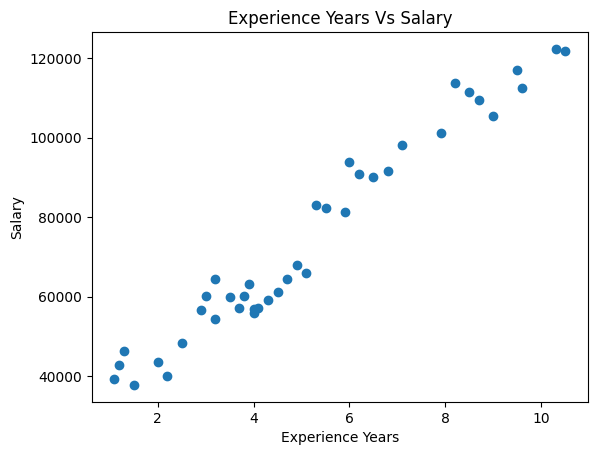

In [8]:
plt.scatter(X, y)
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years Vs Salary")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

* Increasing, as we see from the scatter plot more experience = higher salary.


### Step 7. Initialize a regression model

In [9]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Train the model on the training set

In [11]:
model.fit(X_train, y_train)

LinearRegression()

### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [12]:
slope = round(model.coef_[0])
intercept = round(model.intercept_)

print("Slope is:", slope)
print("Intercept is:", intercept)

Slope is: 9408
Intercept is: 26716


### Step 9.c how much salary does a person get with 2 years of experience?

Explain: Salary = (slope × Experience) + intercept

Salary = (9408 * 2) + 26716

Salary = 18,816 + 26716

Salary = 45,532

In [13]:
print("The Expected Salary is: " , model.predict([[2]]))

The Expected Salary is:  [45532.31272116]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [14]:
increase_salary = slope * 0.5      # 6 months = 0.5 year
print("The salary gain from 6 more months of experience is: " , increase_salary)

The salary gain from 6 more months of experience is:  4704.0


### Step 9.e if one has zero experience, then how much is the estimated salary?

Explain: Salary = (slope × Experience) + intercept

Salary = (9408 * 0) + 26716

Salary = 0 + 26716

Salary = 26716

In [15]:
print("if one has 0 experience the estimated salary is:" , intercept)

if one has 0 experience the estimated salary is: 26716


### Step 10. Evaluate the model on the test set

In [16]:
model.score(X_test, y_test)

0.9068577573647874

### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [17]:
sample_values = X_test.sample(3, random_state=42)
predicted_values = model.predict(sample_values)

check_matching = pd.DataFrame({
"Experience Years" : sample_values["Experience Years"],
"Predicted_Values (Salary)" : predicted_values,
"True_Values (Salary)" : y_test.loc[sample_values.index]
})

check_matching

,Experience Years,Predicted_Values (Salary),True_Values (Salary)
16,4.0,64348.375266,56957
12,3.7,61525.965884,57189
19,4.5,69052.390902,61111


### Step 12. Plot the data and the regression line

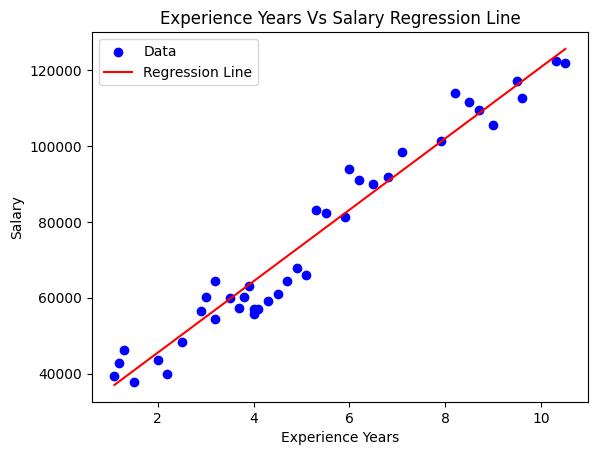

In [18]:
plt.scatter(X, y, color="blue" , label="Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years Vs Salary Regression Line")
plt.legend()
plt.show()